In [15]:
import sys
sys.path.append("..")
from utils.utils import * 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

## Data inspection

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   VEHICLECLASS              1067 non-null   object 
 1   ENGINESIZE                1067 non-null   float64
 2   CYLINDERS                 1067 non-null   int64  
 3   TRANSMISSION              1067 non-null   object 
 4   FUELTYPE                  1067 non-null   object 
 5   FUELCONSUMPTION_CITY      1067 non-null   float64
 6   FUELCONSUMPTION_HWY       1067 non-null   float64
 7   FUELCONSUMPTION_COMB      1067 non-null   float64
 8   FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 75.1+ KB


array([[<Axes: title={'center': 'MODELYEAR'}>,
        <Axes: title={'center': 'ENGINESIZE'}>,
        <Axes: title={'center': 'CYLINDERS'}>],
       [<Axes: title={'center': 'FUELCONSUMPTION_CITY'}>,
        <Axes: title={'center': 'FUELCONSUMPTION_HWY'}>,
        <Axes: title={'center': 'FUELCONSUMPTION_COMB'}>],
       [<Axes: title={'center': 'FUELCONSUMPTION_COMB_MPG'}>,
        <Axes: title={'center': 'CO2EMISSIONS'}>, <Axes: >]], dtype=object)

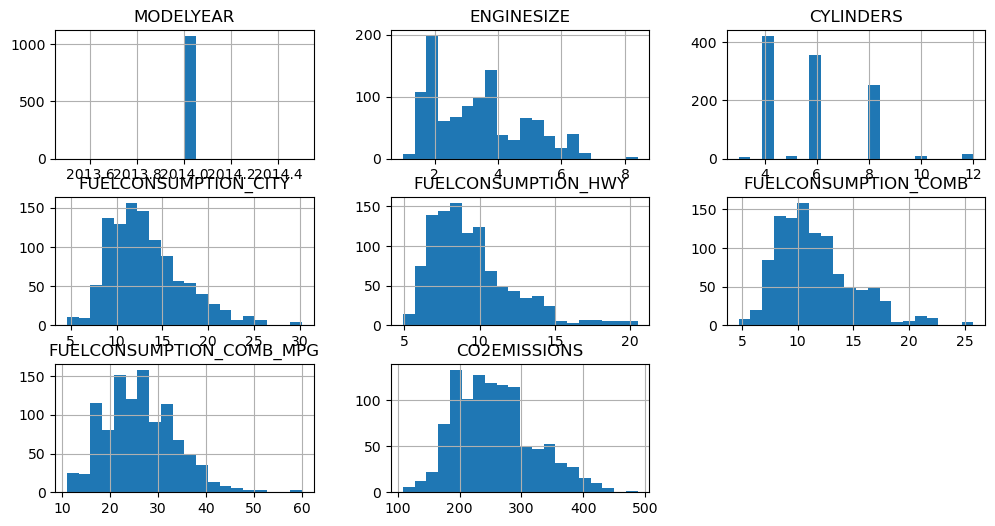

In [16]:
df = pd.read_csv("../data/fuel.csv")
X = df.drop(["MODELYEAR", "MAKE", "MODEL", "CO2EMISSIONS"], axis=1)
y = df["CO2EMISSIONS"]
display(df.head())
display(df.isnull().sum())
X.info()
df.hist(figsize=(12,6), bins=20)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_num = X.select_dtypes(include=["number"])

data_corr = X_num.copy()
data_corr["target"] = y

corr_with_y = data_corr.corr()["target"].drop("target")

display(corr_with_y.sort_values(ascending=False))


FUELCONSUMPTION_CITY        0.898039
FUELCONSUMPTION_COMB        0.892129
ENGINESIZE                  0.874154
FUELCONSUMPTION_HWY         0.861748
CYLINDERS                   0.849685
FUELCONSUMPTION_COMB_MPG   -0.906394
Name: target, dtype: float64

## Preprocessing

In [18]:
num_pipeline = make_pipeline(
    StandardScaler()
)

cat_pipeline = make_pipeline(
    OneHotEncoder(handle_unknown="ignore")
)

num_attribs = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_attribs = X_train.select_dtypes(exclude=["number"]).columns.tolist()

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

## Model

In [19]:
reg = make_pipeline(
    preprocessing,
    LinearRegression()
)

reg.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluation

Test R2: 0.9921130716079841
Test MSE: 32.61201904306659
Test RMSE: 5.710693394244397
Test MAE: 3.4620107568307854


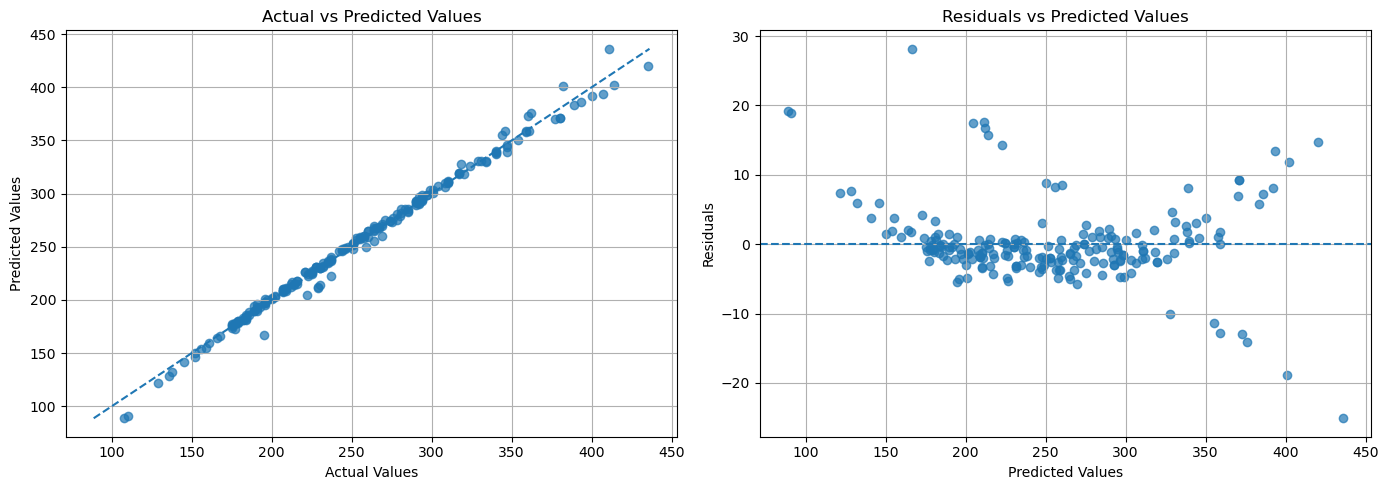

In [20]:
evaluate_regression(reg, X_test, y_test)